# 3 Dataset a analýza dat

Tento notebook slouží k základní explorativní analýze datasetu použitého pro klasifikaci dětského pláče.

Cílem notebooku je:

- zjistit celkový počet nahrávek,
- analyzovat distribuci cílových tříd,
- popsat rozložení pohlaví a věkových kategorií dítěte,
- ověřit základní technické vlastnosti zvukových souborů,
- extrahovat agregované MFCC příznaky,
- provést základní explorativní analýzu příznakového prostoru.

Součástí analýzy je zejména posouzení rozložení vybraných MFCC příznaků, korelační struktury příznaků, projekce dat pomocí PCA a t-SNE a orientační posouzení shlukovatelnosti pomocí algoritmu k-means.

Výstupy z notebooku slouží jako podklad pro popis datasetu, analytickou část práce a následnou přípravu klasifikačních modelů.

In [1]:
import os
import wave
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

In [2]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

BASE_PATH = os.path.join("..", "dataset")
OUTPUT_DIR = os.path.join("..", "outputs", "figures")
FEATURES_OUTPUT_PATH = os.path.join("..", "outputs", "features.csv")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.dirname(FEATURES_OUTPUT_PATH), exist_ok=True)

In [3]:
POHLAVI_MAP = {
    "m": "chlapec",
    "f": "dívka"
}

VEK_MAP = {
    "04": "0–4 týdny",
    "48": "4–8 týdnů",
    "26": "2–6 měsíců",
    "72": "7 měsíců–2 roky",
    "22": "více než 2 roky"
}

VEK_PORADI = [
    "0–4 týdny",
    "4–8 týdnů",
    "2–6 měsíců",
    "7 měsíců–2 roky",
    "více než 2 roky"
]

TRIDA_MAP_CZ = {
    "hungry": "hlad",
    "discomfort": "nepohodlí",
    "tired": "únava",
    "belly_pain": "bolest břicha",
    "belly pain": "bolest břicha",
    "burping": "říhání"
}

PORADI_TRID = ["hlad", "nepohodlí", "únava", "bolest břicha", "říhání"]

## 3.1 Načtení metadat a základní popis datasetu

Metadata jsou získána přímo z názvů zvukových souborů. Z názvu lze určit zejména pohlaví dítěte, věkovou kategorii a kód cílové třídy. V této části je vytvořena základní metadatová tabulka, která slouží jako výchozí bod pro další popis a analýzu datasetu.

In [4]:
def parse_metadata_from_filename(filename):
    
    name, ext = os.path.splitext(filename)
    parts = name.split("-")

    if len(parts) < 5:
        return None

    reason = parts[-1].lower()
    age_code = parts[-2]
    gender_code = parts[-3].lower()
    app_version = parts[-4]
    timestamp = parts[-5]

    return {
        "soubor": filename,
        "format": ext.lower(),
        "casove_razitko": timestamp,
        "verze_aplikace": app_version,
        "kod_pohlavi": gender_code,
        "pohlavi": POHLAVI_MAP.get(gender_code, "neznámé"),
        "kod_veku": age_code,
        "vekova_kategorie": VEK_MAP.get(age_code, "neznámé"),
        "kod_tridy": reason
    }


def get_wav_properties(file_path):

    with wave.open(file_path, "rb") as wav_file:
        sample_rate = wav_file.getframerate()
        sample_width_bytes = wav_file.getsampwidth()
        channels = wav_file.getnchannels()
        n_frames = wav_file.getnframes()
        duration_sec = n_frames / sample_rate if sample_rate else 0

    return {
        "vzorkovaci_frekvence_hz": sample_rate,
        "bitova_hloubka": sample_width_bytes * 8,
        "pocet_kanalu": channels,
        "delka_s": round(duration_sec, 3)
    }

In [5]:
records = []

for class_name in os.listdir(BASE_PATH):
    class_path = os.path.join(BASE_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        if not file.lower().endswith(".wav"):
            continue

        file_path = os.path.join(class_path, file)
        metadata = parse_metadata_from_filename(file)

        if metadata is not None:
            metadata["trida"] = class_name
            metadata["cesta"] = file_path
            records.append(metadata)

df_meta = pd.DataFrame(records)
df_meta["trida_cz"] = df_meta["trida"].replace(TRIDA_MAP_CZ)

print(f"Celkový počet nahrávek: {len(df_meta)}")
df_meta.head()

Celkový počet nahrávek: 457


,soubor,format,casove_razitko,verze_aplikace,kod_pohlavi,pohlavi,kod_veku,vekova_kategorie,kod_tridy,trida,cesta,trida_cz
0,549a46d8-9c84-430e-ade8-97eae2bef787-143013077...,.wav,1430130772174,1.7,m,chlapec,48,4–8 týdnů,bp,belly_pain,..\dataset\belly_pain\549a46d8-9c84-430e-ade8-...,bolest břicha
1,643D64AD-B711-469A-AF69-55C0D5D3E30F-143013849...,.wav,1430138495,1.0,m,chlapec,72,7 měsíců–2 roky,bp,belly_pain,..\dataset\belly_pain\643D64AD-B711-469A-AF69-...,bolest břicha
2,643D64AD-B711-469A-AF69-55C0D5D3E30F-143013850...,.wav,1430138506,1.0,m,chlapec,72,7 měsíců–2 roky,bp,belly_pain,..\dataset\belly_pain\643D64AD-B711-469A-AF69-...,bolest břicha
3,643D64AD-B711-469A-AF69-55C0D5D3E30F-143013851...,.wav,1430138514,1.0,m,chlapec,72,7 měsíců–2 roky,bp,belly_pain,..\dataset\belly_pain\643D64AD-B711-469A-AF69-...,bolest břicha
4,643D64AD-B711-469A-AF69-55C0D5D3E30F-143013852...,.wav,1430138524,1.0,m,chlapec,72,7 měsíců–2 roky,bp,belly_pain,..\dataset\belly_pain\643D64AD-B711-469A-AF69-...,bolest břicha


## 3.2 Distribuce tříd

Následující tabulka shrnuje zastoupení jednotlivých tříd v datasetu. Kromě absolutního počtu nahrávek uvádí i relativní podíl každé třídy. Tato informace je důležitá zejména pro posouzení vyváženosti klasifikační úlohy, protože výrazná převaha některé třídy může ovlivnit následné trénování i vyhodnocování klasifikačních modelů.

In [6]:
tridy_counts = df_meta["trida_cz"].value_counts().reindex(PORADI_TRID, fill_value=0)

tridy_summary = pd.DataFrame({
    "Počet nahrávek": tridy_counts,
    "Podíl (%)": (tridy_counts / len(df_meta) * 100).round(2)
})

tridy_summary.loc["Celkem"] = [tridy_counts.sum(), 100.00]
tridy_summary.to_csv(os.path.join(OUTPUT_DIR, "distribuce_trid.csv"), encoding="utf-8-sig")

tridy_summary

,Počet nahrávek,Podíl (%)
trida_cz,,
hlad,382.0,83.59
nepohodlí,27.0,5.91
únava,24.0,5.25
bolest břicha,16.0,3.50
říhání,8.0,1.75
Celkem,457.0,100.00


## 3.3 Kontrola technických vlastností WAV souborů

Pro ověření konzistence datasetu byla provedena kontrola základních technických parametrů zvukových souborů. Posuzován byl formát souboru, vzorkovací frekvence, bitová hloubka a počet kanálů. Cílem je ověřit, zda mají zvukové soubory jednotné technické parametry před dalším zpracováním.

In [7]:
wav_properties = df_meta["cesta"].apply(get_wav_properties)
wav_df = pd.DataFrame(list(wav_properties))

df_meta = pd.concat([df_meta, wav_df], axis=1)

In [8]:
technicka_kontrola = pd.DataFrame({
    "Parametr": [
        "Formát souboru",
        "Vzorkovací frekvence",
        "Bitová hloubka",
        "Počet kanálů"
    ],
    "Unikátní hodnoty": [
        ", ".join(map(str, sorted(df_meta["format"].dropna().unique()))),
        ", ".join(map(str, sorted(df_meta["vzorkovaci_frekvence_hz"].dropna().unique()))),
        ", ".join(map(str, sorted(df_meta["bitova_hloubka"].dropna().unique()))),
        ", ".join(map(str, sorted(df_meta["pocet_kanalu"].dropna().unique())))
    ],
    "Počet unikátních hodnot": [
        df_meta["format"].nunique(),
        df_meta["vzorkovaci_frekvence_hz"].nunique(),
        df_meta["bitova_hloubka"].nunique(),
        df_meta["pocet_kanalu"].nunique()
    ]
})

technicka_kontrola

,Parametr,Unikátní hodnoty,Počet unikátních hodnot
0,Formát souboru,.wav,1
1,Vzorkovací frekvence,8000,1
2,Bitová hloubka,16,1
3,Počet kanálů,1,1


## 3.4 Rozložení pohlaví dítěte

V této části je analyzováno zastoupení nahrávek podle pohlaví dítěte. Výsledek je zobrazen graficky i tabulkově.

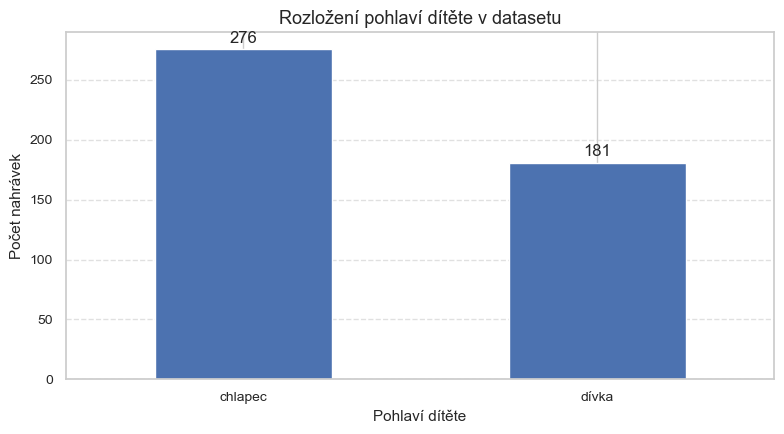

In [9]:
gender_counts = df_meta["pohlavi"].value_counts().reindex(["chlapec", "dívka"], fill_value=0)

ax = gender_counts.plot(kind="bar")
ax.set_title("Rozložení pohlaví dítěte v datasetu")
ax.set_xlabel("Pohlaví dítěte")
ax.set_ylabel("Počet nahrávek")
ax.set_xticklabels(gender_counts.index, rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.6)

for i, value in enumerate(gender_counts.values):
    ax.text(i, value + max(gender_counts.values) * 0.01, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rozlozeni_pohlavi.png"), dpi=300, bbox_inches="tight")
plt.show()

In [10]:
pohlavi_summary = pd.DataFrame({
    "Počet nahrávek": gender_counts,
    "Podíl (%)": (gender_counts / len(df_meta) * 100).round(2)
})

pohlavi_summary.loc["Celkem"] = [gender_counts.sum(), 100.00]

pohlavi_summary

,Počet nahrávek,Podíl (%)
pohlavi,,
chlapec,276.0,60.39
dívka,181.0,39.61
Celkem,457.0,100.00


## 3.5 Rozložení věkových kategorií

Následující analýza popisuje zastoupení nahrávek podle věkové kategorie dítěte. Stejně jako v předchozí části je výsledek prezentován grafem a souhrnnou tabulkou.

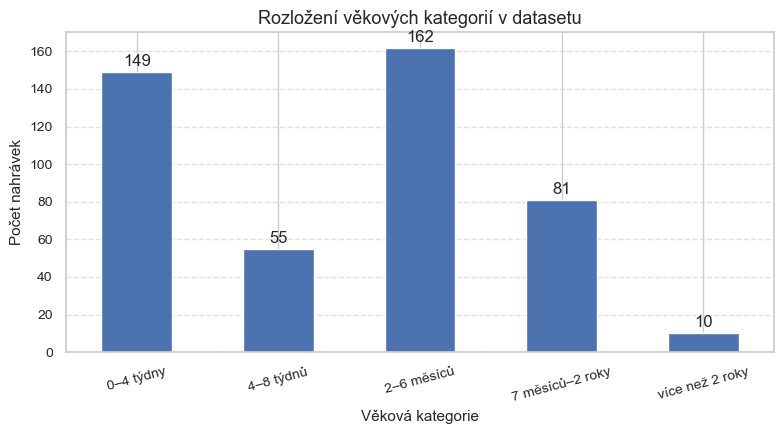

In [11]:
age_counts = df_meta["vekova_kategorie"].value_counts().reindex(VEK_PORADI, fill_value=0)

ax = age_counts.plot(kind="bar")
ax.set_title("Rozložení věkových kategorií v datasetu")
ax.set_xlabel("Věková kategorie")
ax.set_ylabel("Počet nahrávek")
ax.set_xticklabels(age_counts.index, rotation=15)
ax.grid(axis="y", linestyle="--", alpha=0.6)

for i, value in enumerate(age_counts.values):
    ax.text(i, value + max(age_counts.values) * 0.01, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rozlozeni_veku.png"), dpi=300, bbox_inches="tight")
plt.show()

In [12]:
vek_summary = pd.DataFrame({
    "Počet nahrávek": age_counts,
    "Podíl (%)": (age_counts / len(df_meta) * 100).round(2)
})

vek_summary.loc["Celkem"] = [age_counts.sum(), 100.00]

vek_summary

,Počet nahrávek,Podíl (%)
vekova_kategorie,,
0–4 týdny,149.0,32.60
4–8 týdnů,55.0,12.04
2–6 měsíců,162.0,35.45
7 měsíců–2 roky,81.0,17.72
více než 2 roky,10.0,2.19
Celkem,457.0,100.00


## 3.6 Shrnutí základního průzkumu datasetu

Základní analýza datasetu ukázala celkový počet nahrávek, distribuci cílových tříd i rozložení metadatových charakteristik. Současně bylo ověřeno, že zvukové soubory mají jednotné technické parametry, což vytváří vhodný základ pro další extrakci akustických příznaků. Dataset je však výrazně nevyvážený, protože jedna třída tvoří převážnou část všech nahrávek. Tato skutečnost musí být zohledněna při následném trénování a vyhodnocování klasifikačních modelů.

## 3.7 Extrakce MFCC příznaků pro explorativní analýzu

Pro každou nahrávku jsou v této části vypočteny agregované MFCC příznaky. Z každého z prvních 13 MFCC koeficientů je uložena průměrná hodnota a směrodatná odchylka. Tím vzniká statický vektor příznaků, který umožňuje porovnávání nahrávek a následnou analýzu příznakového prostoru. Tento způsob reprezentace zachycuje základní spektrální charakteristiky nahrávky, ale nezachovává její detailní časový průběh.

In [13]:
N_MFCC = 13
TARGET_SR = 8000

def extract_mfcc_features(file_path, n_mfcc=N_MFCC, sr=TARGET_SR):
    signal, sample_rate = librosa.load(file_path, sr=sr, mono=True)
    mfcc = librosa.feature.mfcc(y=signal, sr=sample_rate, n_mfcc=n_mfcc)

    features = {}

    for i in range(n_mfcc):
        coef_values = mfcc[i]
        features[f"mfcc_{i+1}_mean"] = float(np.mean(coef_values))
        features[f"mfcc_{i+1}_std"] = float(np.std(coef_values))

    features["delka_signalu_s"] = round(len(signal) / sample_rate, 3)
    features["vzorkovaci_frekvence_hz"] = sample_rate

    return features

In [14]:
records_features = []
errors = []

for class_name in os.listdir(BASE_PATH):
    class_path = os.path.join(BASE_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        if not file.lower().endswith(".wav"):
            continue

        file_path = os.path.join(class_path, file)

        try:
            metadata = parse_metadata_from_filename(file)
            if metadata is None:
                errors.append((file, "Nepodařilo se zpracovat metadata z názvu souboru"))
                continue

            mfcc_features = extract_mfcc_features(file_path, n_mfcc=N_MFCC, sr=TARGET_SR)

            row = {
                "trida": class_name,
                "cesta": file_path
            }
            row.update(metadata)
            row.update(mfcc_features)

            records_features.append(row)

        except Exception as e:
            errors.append((file, str(e)))

df_features = pd.DataFrame(records_features)
df_features["trida_cz"] = df_features["trida"].replace(TRIDA_MAP_CZ)

print(f"Počet úspěšně zpracovaných nahrávek: {len(df_features)}")
print(f"Počet chyb: {len(errors)}")

Počet úspěšně zpracovaných nahrávek: 457
Počet chyb: 0


In [15]:
if errors:
    df_errors = pd.DataFrame(errors, columns=["Soubor", "Chyba"])
    display(df_errors.head(20))
else:
    print("Všechny soubory byly zpracovány bez chyby.")

Všechny soubory byly zpracovány bez chyby.


In [16]:
df_features.head()

,trida,cesta,soubor,format,casove_razitko,verze_aplikace,kod_pohlavi,pohlavi,kod_veku,vekova_kategorie,...,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,delka_signalu_s,vzorkovaci_frekvence_hz,trida_cz
0,belly_pain,..\dataset\belly_pain\549a46d8-9c84-430e-ade8-...,549a46d8-9c84-430e-ade8-97eae2bef787-143013077...,.wav,1430130772174,1.7,m,chlapec,48,4–8 týdnů,...,6.247529,-9.528886,8.201892,2.925496,13.255345,12.073723,19.602213,6.86,8000,bolest břicha
1,belly_pain,..\dataset\belly_pain\643D64AD-B711-469A-AF69-...,643D64AD-B711-469A-AF69-55C0D5D3E30F-143013849...,.wav,1430138495,1.0,m,chlapec,72,7 měsíců–2 roky,...,5.700343,-15.466560,6.321782,-7.020199,7.385770,-10.439179,10.349353,7.00,8000,bolest břicha
2,belly_pain,..\dataset\belly_pain\643D64AD-B711-469A-AF69-...,643D64AD-B711-469A-AF69-55C0D5D3E30F-143013850...,.wav,1430138506,1.0,m,chlapec,72,7 měsíců–2 roky,...,8.057078,-10.691089,10.224451,-6.565115,9.808588,-10.446559,9.109766,7.00,8000,bolest břicha
3,belly_pain,..\dataset\belly_pain\643D64AD-B711-469A-AF69-...,643D64AD-B711-469A-AF69-55C0D5D3E30F-143013851...,.wav,1430138514,1.0,m,chlapec,72,7 měsíců–2 roky,...,11.125185,-8.505555,11.139976,-0.132468,16.584368,-0.643279,17.467115,7.00,8000,bolest břicha
4,belly_pain,..\dataset\belly_pain\643D64AD-B711-469A-AF69-...,643D64AD-B711-469A-AF69-55C0D5D3E30F-143013852...,.wav,1430138524,1.0,m,chlapec,72,7 měsíců–2 roky,...,8.216128,-10.158533,10.210486,-4.346590,10.568474,-6.528756,9.394225,7.00,8000,bolest břicha


In [17]:
mfcc_mean_cols = [f"mfcc_{i}_mean" for i in range(1, N_MFCC + 1)]
mfcc_std_cols = [f"mfcc_{i}_std" for i in range(1, N_MFCC + 1)]
mfcc_all_cols = mfcc_mean_cols + mfcc_std_cols

missing_summary = df_features[mfcc_all_cols].isnull().sum()
missing_summary = missing_summary[missing_summary > 0]

if len(missing_summary) == 0:
    print("V MFCC příznacích nebyly nalezeny žádné chybějící hodnoty.")
else:
    display(missing_summary.to_frame("Počet chybějících hodnot"))

V MFCC příznacích nebyly nalezeny žádné chybějící hodnoty.


In [18]:
df_features.to_csv(FEATURES_OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"Tabulka příznaků byla uložena do: {FEATURES_OUTPUT_PATH}")

Tabulka příznaků byla uložena do: ..\outputs\features.csv


## 3.8 Explorativní analýza příznakového prostoru

Na základě extrahovaných MFCC příznaků je dále analyzována struktura datového prostoru. Pozornost je zaměřena na distribuci vybraných příznaků mezi třídami, lineární vztahy mezi příznaky, geometrickou strukturu dat ve zmenšeném prostoru a míru shody mezi přirozeným shlukováním a anotovanými třídami.

### 3.8.1 Distribuce vybraných MFCC příznaků podle tříd

Pro ilustraci překryvu distribucí byly zvoleny dva vybrané příznaky – průměrné hodnoty MFCC 1 a MFCC 2. Cílem je orientačně posoudit, do jaké míry tyto jednotlivé příznaky samostatně rozlišují mezi třídami pláče.

In [19]:
vybrane_priznaky = ["mfcc_1_mean", "mfcc_2_mean"]

df_long = df_features.melt(
    id_vars=["trida", "trida_cz"],
    value_vars=vybrane_priznaky,
    var_name="priznak",
    value_name="hodnota"
)

nazvy_priznaku_cz = {
    "mfcc_1_mean": "MFCC 1 – průměr",
    "mfcc_2_mean": "MFCC 2 – průměr"
}

df_long["priznak_cz"] = df_long["priznak"].map(nazvy_priznaku_cz)

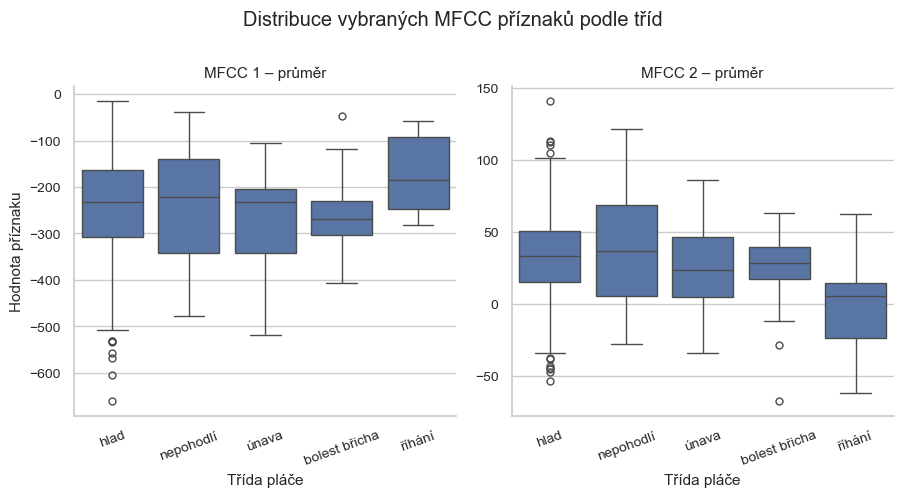

In [20]:
g = sns.catplot(
    data=df_long,
    x="trida_cz",
    y="hodnota",
    col="priznak_cz",
    kind="box",
    order=PORADI_TRID,
    sharey=False,
    height=4.8,
    aspect=0.95
)

g.set_axis_labels("Třída pláče", "Hodnota příznaku")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=20)

g.fig.subplots_adjust(top=0.82)
g.fig.suptitle("Distribuce vybraných MFCC příznaků podle tříd")

output_path_box = os.path.join(OUTPUT_DIR, "mfcc_boxploty_tridy.png")
g.savefig(output_path_box, dpi=300, bbox_inches="tight")

plt.show()

### 3.8.2 Korelační struktura příznakového prostoru

Dalším krokem je analýza lineárních vztahů mezi jednotlivými MFCC příznaky. Korelační matice umožňuje identifikovat příznaky, které nesou podobnou informaci, a orientačně posoudit míru redundance v příznakovém prostoru.

In [21]:
corr_matrix = df_features[mfcc_all_cols].corr(method="pearson")

short_labels = (
    [f"M{i} prům." for i in range(1, N_MFCC + 1)] +
    [f"M{i} sm.odch." for i in range(1, N_MFCC + 1)]
)

corr_matrix_labeled = corr_matrix.copy()
corr_matrix_labeled.index = short_labels
corr_matrix_labeled.columns = short_labels

mask = np.triu(np.ones_like(corr_matrix_labeled, dtype=bool))

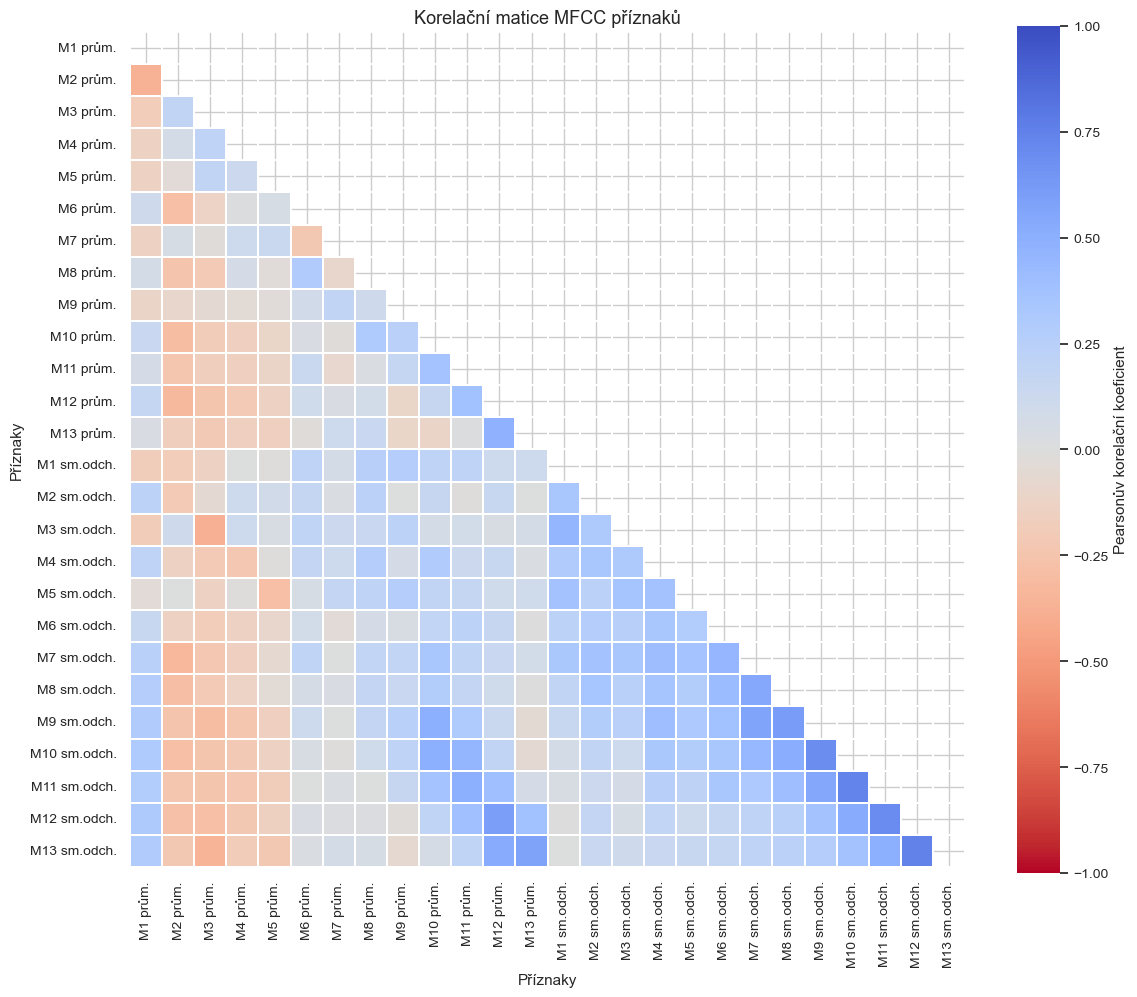

In [22]:
plt.figure(figsize=(12, 10))

ax = sns.heatmap(
    corr_matrix_labeled,
    mask=mask,
    cmap="coolwarm_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"label": "Pearsonův korelační koeficient"}
)

ax.set_title("Korelační matice MFCC příznaků")
ax.set_xlabel("Příznaky")
ax.set_ylabel("Příznaky")

plt.tight_layout()

output_path_corr_tri = os.path.join(OUTPUT_DIR, "korelacni_matice_mfcc_trojuhelnik.png")
plt.savefig(output_path_corr_tri, dpi=300, bbox_inches="tight")
plt.show()

In [23]:
corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
).stack().reset_index()

corr_pairs.columns = ["Příznak 1", "Příznak 2", "Korelace"]
corr_pairs["Absolutní korelace"] = corr_pairs["Korelace"].abs()

top_corr = corr_pairs.sort_values("Absolutní korelace", ascending=False).head(10)
top_corr

,Příznak 1,Příznak 2,Korelace,Absolutní korelace
649,mfcc_12_std,mfcc_13_std,0.746888,0.746888
595,mfcc_10_std,mfcc_11_std,0.736107,0.736107
622,mfcc_11_std,mfcc_12_std,0.700842,0.700842
568,mfcc_9_std,mfcc_10_std,0.692635,0.692635
541,mfcc_8_std,mfcc_9_std,0.613881,0.613881
310,mfcc_12_mean,mfcc_12_std,0.595180,0.595180
337,mfcc_13_mean,mfcc_13_std,0.575920,0.575920
515,mfcc_7_std,mfcc_9_std,0.568244,0.568244
569,mfcc_9_std,mfcc_11_std,0.554589,0.554589
514,mfcc_7_std,mfcc_8_std,0.539214,0.539214


### 3.8.3 Geometrická struktura příznakového prostoru

Pro orientační posouzení struktury dat ve vysokodimenzionálním prostoru MFCC příznaků jsou využity dvě metody redukce dimenze. PCA představuje lineární projekci maximalizující zachycenou variabilitu, zatímco t-SNE slouží k nelineárnímu zobrazení lokálních podobností mezi vzorky. Před aplikací těchto metod jsou příznaky standardizovány, aby rozdílné rozsahy hodnot jednotlivých příznaků nepřiměřeně neovlivnily výslednou projekci. Cílem není finální klasifikace, ale vizuální posouzení separability tříd.

In [24]:
X = df_features[mfcc_all_cols].copy()
y = df_features["trida_cz"].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### PCA projekce do dvou dimenzí

In [25]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
explained_total = explained_var.sum() * 100

print(f"Vysvětlená variance PC1: {explained_var[0] * 100:.2f} %")
print(f"Vysvětlená variance PC2: {explained_var[1] * 100:.2f} %")
print(f"Celkem vysvětleno prvními dvěma komponentami: {explained_total:.2f} %")

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Třída pláče": y.values
})

Vysvětlená variance PC1: 24.10 %
Vysvětlená variance PC2: 10.62 %
Celkem vysvětleno prvními dvěma komponentami: 34.71 %


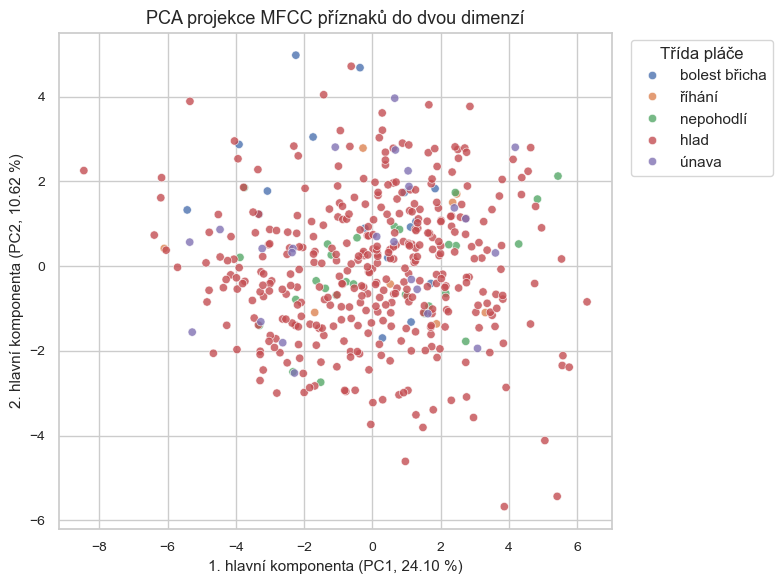

In [26]:
plt.figure(figsize=(8, 6))

ax = sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Třída pláče",
    alpha=0.8
)

ax.set_title("PCA projekce MFCC příznaků do dvou dimenzí")
ax.set_xlabel(f"1. hlavní komponenta (PC1, {explained_var[0] * 100:.2f} %)")
ax.set_ylabel(f"2. hlavní komponenta (PC2, {explained_var[1] * 100:.2f} %)")

plt.legend(title="Třída pláče", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

output_path_pca = os.path.join(OUTPUT_DIR, "pca_mfcc_2d.png")
plt.savefig(output_path_pca, dpi=300, bbox_inches="tight")
plt.show()

#### t-SNE projekce do dvou dimenzí

Metoda t-SNE je použita jako nelineární technika redukce dimenze, která se zaměřuje především na zachování lokálních podobností mezi nahrávkami. Výsledná projekce slouží pouze k vizuální interpretaci struktury dat, nikoliv jako podklad pro přímé kvantitativní hodnocení vzdáleností mezi třídami.

In [27]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame({
    "Dimenze 1": X_tsne[:, 0],
    "Dimenze 2": X_tsne[:, 1],
    "Třída pláče": y.values
})

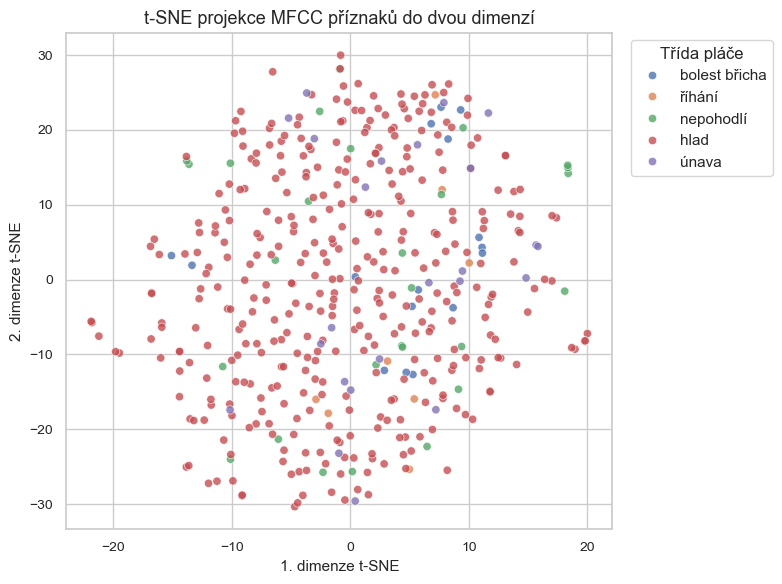

In [28]:
plt.figure(figsize=(8, 6))

ax = sns.scatterplot(
    data=df_tsne,
    x="Dimenze 1",
    y="Dimenze 2",
    hue="Třída pláče",
    alpha=0.8
)

ax.set_title("t-SNE projekce MFCC příznaků do dvou dimenzí")
ax.set_xlabel("1. dimenze t-SNE")
ax.set_ylabel("2. dimenze t-SNE")

plt.legend(title="Třída pláče", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

output_path_tsne = os.path.join(OUTPUT_DIR, "tsne_mfcc_2d.png")
plt.savefig(output_path_tsne, dpi=300, bbox_inches="tight")
plt.show()

#### Kumulativní vysvětlená variance PCA

Pro lepší pochopení struktury dat je dále sledován kumulativní podíl vysvětlené variance v závislosti na počtu hlavních komponent. Cílem je odhadnout, kolik komponent je potřeba k zachycení podstatné části variability dat.

In [29]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

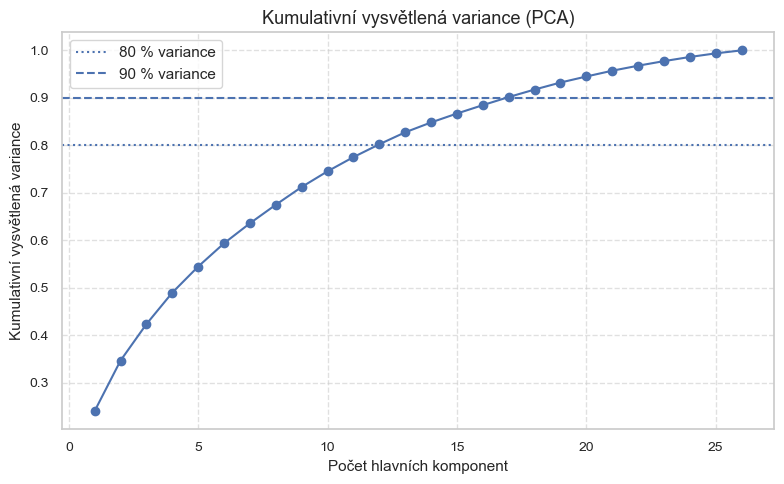

In [30]:
plt.figure(figsize=(8, 5))

x = np.arange(1, len(cumulative_variance) + 1)

plt.plot(x, cumulative_variance, marker="o")
plt.title("Kumulativní vysvětlená variance (PCA)")
plt.xlabel("Počet hlavních komponent")
plt.ylabel("Kumulativní vysvětlená variance")

plt.axhline(y=0.8, linestyle=":", label="80 % variance")
plt.axhline(y=0.9, linestyle="--", label="90 % variance")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

output_path_var = os.path.join(OUTPUT_DIR, "pca_kumulativni_variance.png")
plt.savefig(output_path_var, dpi=300, bbox_inches="tight")
plt.show()

### 3.8.4 Orientační posouzení shlukovatelnosti

V této části je zkoumáno, do jaké míry přirozená geometrie příznakového prostoru odpovídá anotovaným třídám pláče. Pro tento účel je použit algoritmus k-means s počtem shluků rovným počtu tříd. Výsledky jsou následně porovnány se skutečnými třídami pomocí metrik ARI a NMI. Tato analýza neslouží jako klasifikační model, ale pouze jako orientační posouzení toho, zda se anotované třídy spontánně formují do oddělených shluků.

In [31]:
n_classes = df_features["trida"].nunique()

kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

ari = adjusted_rand_score(df_features["trida"], clusters)
nmi = normalized_mutual_info_score(df_features["trida"], clusters)

results_table = pd.DataFrame({
    "Metrika": ["Adjusted Rand Index (ARI)", "Normalized Mutual Information (NMI)"],
    "Hodnota": [round(ari, 4), round(nmi, 4)]
})

results_table

,Metrika,Hodnota
0,Adjusted Rand Index (ARI),0.0010
1,Normalized Mutual Information (NMI),0.0212


In [32]:
df_vis = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Třída pláče": df_features["trida_cz"].values,
    "Shluk": clusters
})

Následující obrázky porovnávají rozložení dat v prostoru prvních dvou hlavních komponent PCA podle skutečných tříd pláče a podle shluků nalezených algoritmem k-means. Vizualizace umožňuje orientační porovnání geometrické struktury dat a její shody se sémantickým rozdělením. Je však nutné zohlednit, že jde pouze o dvourozměrnou projekci původního vícerozměrného příznakového prostoru.

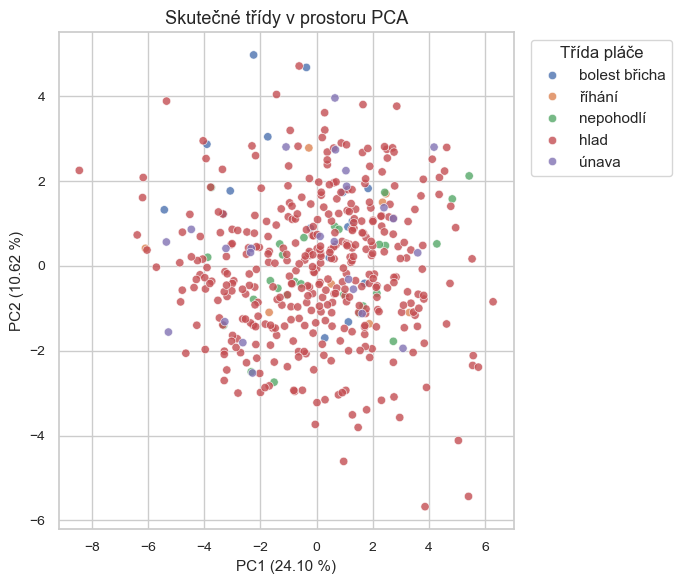

In [33]:
plt.figure(figsize=(7, 6))

ax = sns.scatterplot(
    data=df_vis,
    x="PC1",
    y="PC2",
    hue="Třída pláče",
    alpha=0.8
)

ax.set_title("Skutečné třídy v prostoru PCA")
ax.set_xlabel(f"PC1 ({explained_var[0] * 100:.2f} %)")
ax.set_ylabel(f"PC2 ({explained_var[1] * 100:.2f} %)")

plt.legend(title="Třída pláče", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

output_path_true = os.path.join(OUTPUT_DIR, "kmeans_ground_truth_pca.png")
plt.savefig(output_path_true, dpi=300, bbox_inches="tight")

plt.show()

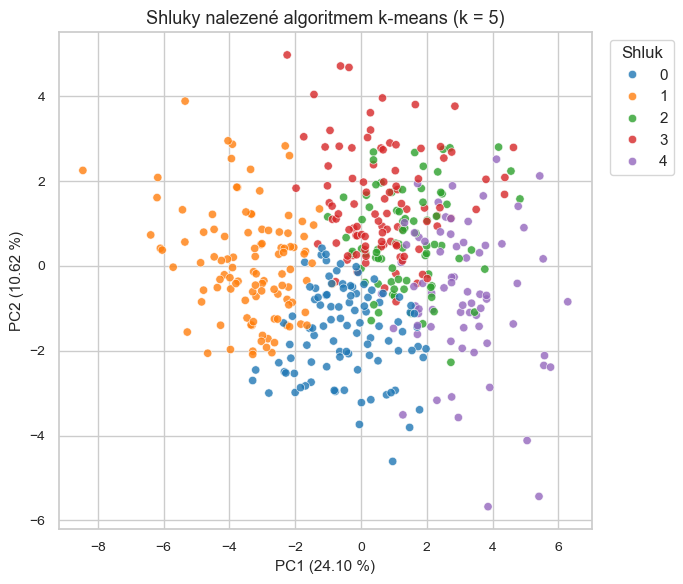

In [34]:
plt.figure(figsize=(7, 6))

ax = sns.scatterplot(
    data=df_vis,
    x="PC1",
    y="PC2",
    hue="Shluk",
    palette="tab10",
    alpha=0.8
)

ax.set_title(f"Shluky nalezené algoritmem k-means (k = {n_classes})")
ax.set_xlabel(f"PC1 ({explained_var[0] * 100:.2f} %)")
ax.set_ylabel(f"PC2 ({explained_var[1] * 100:.2f} %)")

plt.legend(title="Shluk", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

output_path_clusters = os.path.join(OUTPUT_DIR, "kmeans_clusters_pca.png")
plt.savefig(output_path_clusters, dpi=300, bbox_inches="tight")

plt.show()

## 3.9 Shrnutí explorativní analýzy

Explorativní analýza ukazuje, že jednotlivé agregované MFCC příznaky samostatně neposkytují dostatečně silnou separaci tříd, protože jejich distribuce se mezi třídami výrazně překrývají. Současně je patrné, že mezi některými příznaky existují středně silné až silné lineární vztahy, což ukazuje na částečnou redundanci v příznakovém prostoru.

Projekce pomocí PCA i t-SNE naznačují, že třídy dětského pláče nejsou v prostoru agregovaných MFCC příznaků zřetelně oddělené. Velmi nízké hodnoty metrik ARI a NMI při porovnání shluků k-means se skutečnými třídami dále ukazují, že přirozená geometrie dat přímo neodpovídá anotovaným kategoriím pláče. Výsledek shlukové analýzy však nelze chápat jako hodnocení kvality budoucího klasifikačního modelu, ale pouze jako orientační posouzení struktury příznakového prostoru. Tyto poznatky podporují využití řízených klasifikačních metod, které dokáží pracovat s více příznaky současně a zachytit i složitější, případně nelineární vztahy mezi nimi.